# Phase 7A Level 3P：最小输出投影

在不增加教师数据、不重新训练网络、不改变 MPC、模型、初态和五个随机种子的
条件下，将 DNN 原始输出投影到

\[
\left[\max(0,I_{k-1}-2),\ \min(10,I_{k-1}+2)\right].
\]

本实验只判断最小投影能否修复 Level 3 的硬斜率失效，不进入 Level 4。

## 1. 读取冻结验证和投影结果

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd(); OUT=ROOT/'outputs'/'phase7a_level3p_projection'; DATA=ROOT/'data'/'phase7a_level3p_projection'
metrics=json.loads((OUT/'metrics.json').read_text(encoding='utf-8'))
closed=pd.read_csv(DATA/'projected_closed_loop_metrics.csv')
interventions=pd.read_csv(DATA/'projection_interventions.csv')
print(metrics['study_name'], metrics['status'])

phase7a_level3p_minimal_output_projection completed


## 2. Level 3 冻结合同

In [2]:
frozen=pd.DataFrame(metrics['frozen_artifact_verification']).T
display(frozen)
assert len(frozen)==13
assert frozen.matched.all()

,expected_sha256,actual_sha256,matched
src/battery_fast_charge/phase7a_level3_model.py,0f183ee3769a853eca77379daa159b1382d20ff6f6e3d2...,0f183ee3769a853eca77379daa159b1382d20ff6f6e3d2...,True
configs/phase7a_level3_slew.yaml,7ebd8b44cf9c65e81199366131f0518bad35e5b70564ff...,7ebd8b44cf9c65e81199366131f0518bad35e5b70564ff...,True
data/phase7a_level3_slew/combined_teacher_dataset.csv,e246baf09022c62e20721f929e03ee58e521126ac80976...,e246baf09022c62e20721f929e03ee58e521126ac80976...,True
data/phase7a_level3_slew/global_frozen_test.csv,484b71df5f3afe8dfcf33f4202a608f69d7292c1411621...,484b71df5f3afe8dfcf33f4202a608f69d7292c1411621...,True
data/phase7a_level3_slew/terminal_frozen_test.csv,7ba4a2359016a3549997bc3f892a492ed55f77e872fe3d...,7ba4a2359016a3549997bc3f892a492ed55f77e872fe3d...,True
data/phase7a_level3_slew/closed_loop_initial_states.csv,8a62cb6b5db34c875ce50dd4d743bb296bea4b962fbd40...,8a62cb6b5db34c875ce50dd4d743bb296bea4b962fbd40...,True
data/phase7a_level3_slew/closed_loop_trajectories.csv,fd36caa3d480de66e5053355ecf4a708363258eb34de34...,fd36caa3d480de66e5053355ecf4a708363258eb34de34...,True
outputs/phase7a_level3_slew/dnn_offline_metrics.csv,3b7d533824dbe1675fcf729cf6596ee48209e66875ef46...,3b7d533824dbe1675fcf729cf6596ee48209e66875ef46...,True
outputs/phase7a_level3_slew/models/level3_deep_lbfgs_seed_22.npz,1ef506878774b9dbd55229ea66051e817c753d3a5a5199...,1ef506878774b9dbd55229ea66051e817c753d3a5a5199...,True
outputs/phase7a_level3_slew/models/level3_deep_lbfgs_seed_42.npz,2d9fa77bf1a0fde34bd920e48db91f63b49ac6f7ed364c...,2d9fa77bf1a0fde34bd920e48db91f63b49ac6f7ed364c...,True


## 3. 投影介入范围

In [3]:
display(pd.DataFrame([metrics['projection']]))
display(interventions.groupby('seed').size().rename('intervention_count'))
assert metrics['projection']['frozen_raw_violation_count']==48
assert metrics['projection']['projection_intervention_count']==48
assert metrics['projection']['exact_key_overlap_count']==48
assert metrics['projection']['interventions_outside_one_step_count']==0

,frozen_raw_violation_count,projection_intervention_count,exact_key_overlap_count,interventions_within_one_step_count,interventions_outside_one_step_count,frozen_raw_violations_covered_within_one_step_count,all_interventions_near_frozen_raw_violations,all_frozen_raw_violations_covered_nearby,projection_intervention_fraction,maximum_projection_magnitude_a,mean_projection_magnitude_when_active_a
0,48,48,48,48,0,48,True,True,0.003596,0.132667,0.043851


seed
22      7
42     11
73     12
101    10
137     8
Name: intervention_count, dtype: int64

## 4. 五种子闭环严格门槛

,seed,target_reach_fraction,maximum_voltage_violation_v,maximum_slew_violation_a,maximum_current_step_a,projection_intervention_count,speedup,current_nrmse_percent,charge_time_gap_percent
0,22,1.0,0.0,4.440892e-16,2.0,7,894.444195,0.338154,0.869039
1,42,1.0,0.0,0.000000e+00,2.0,11,903.635774,0.294110,0.603758
2,73,1.0,0.0,0.000000e+00,2.0,12,771.622409,0.229878,0.460725
3,101,1.0,0.0,4.440892e-16,2.0,10,650.716835,0.228239,0.778417
4,137,1.0,0.0,0.000000e+00,2.0,8,626.315573,0.291791,0.603758


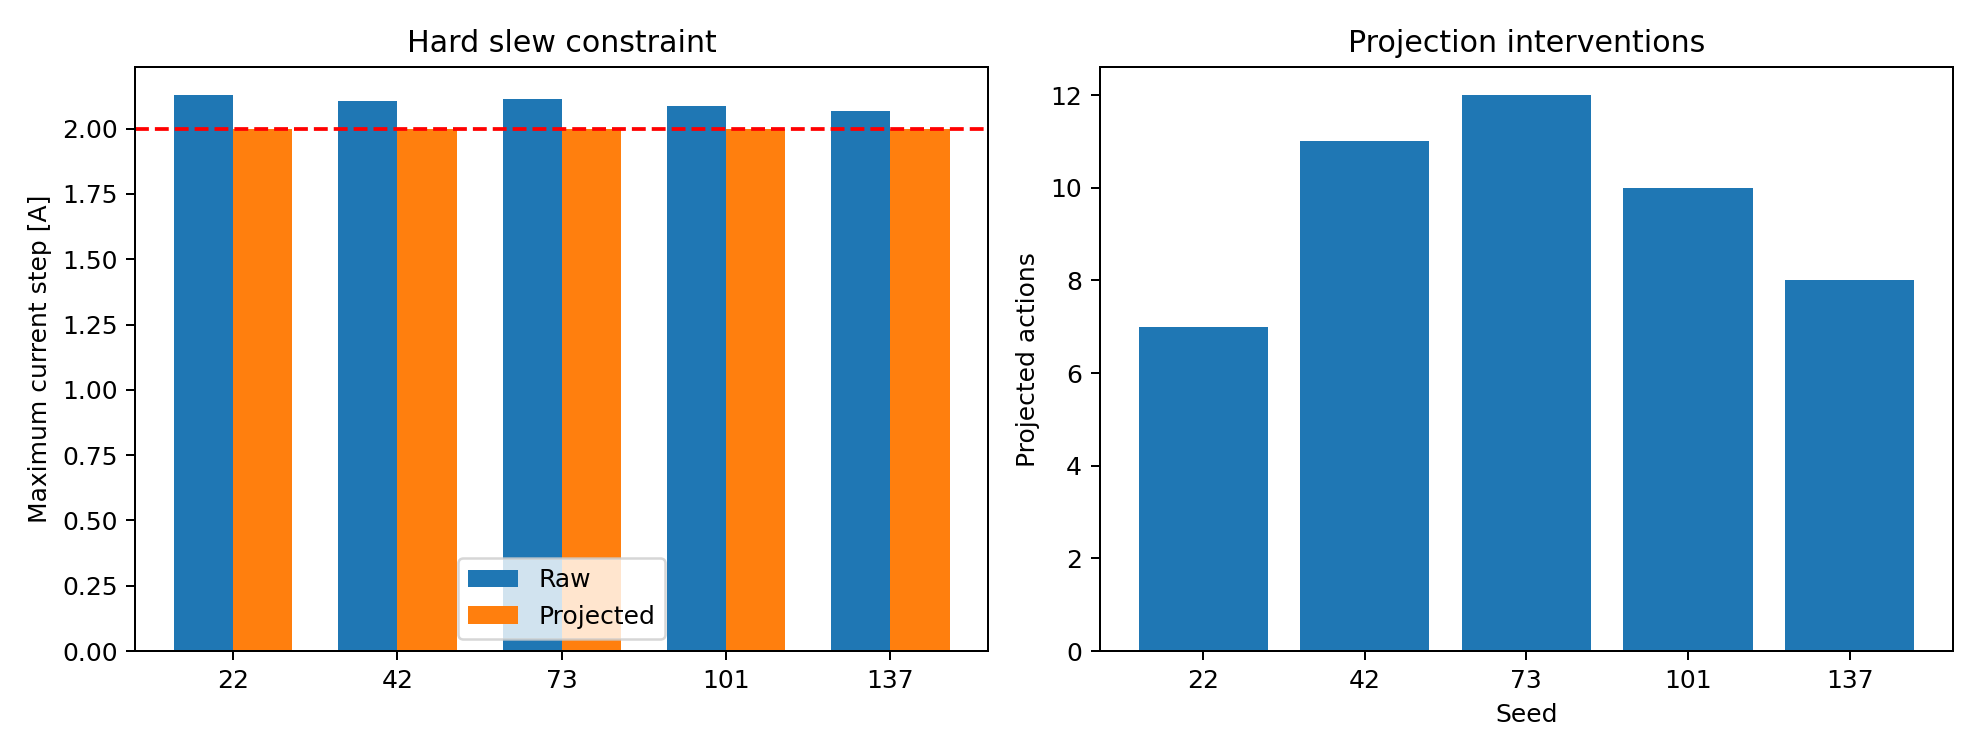

In [4]:
view=closed[['seed','mean_current_nrmse','mean_charge_time_gap_fraction','target_reach_fraction',
             'maximum_voltage_violation_v','maximum_slew_violation_a','maximum_current_step_a',
             'projection_intervention_count','speedup']].copy()
view['current_nrmse_percent']=100*view.pop('mean_current_nrmse')
view['charge_time_gap_percent']=100*view.pop('mean_charge_time_gap_fraction')
display(view)
assert (view.current_nrmse_percent<1).all()
assert (view.charge_time_gap_percent<2).all()
assert (view.target_reach_fraction==1).all()
assert (view.maximum_voltage_violation_v==0).all()
assert (view.maximum_slew_violation_a<=1e-12).all()
assert (view.speedup>100).all()
display(Image(filename=str(OUT/'figures'/'projection_gate_and_interventions.png')))

## 5. 最终判定

In [5]:
display(pd.DataFrame([metrics['decision']['checks']]))
print(metrics['decision']['conclusion'])
assert metrics['decision']['level3p_success']
assert metrics['decision']['proceed_to_level4'] is False

,all_frozen_hashes_match,frozen_raw_violation_count_is_48,zero_slew_violation,all_seed_current_nrmse,all_seed_charge_time_gap,all_seed_target_reach,voltage_constraint_satisfied,current_bounds_satisfied,all_interventions_near_frozen_raw_violations,all_seed_speedup
0,True,True,True,True,True,True,True,True,True,True


Level 3P 最小投影严格通过，研究停止在 Level 3P


## 结论

最小输出投影只介入冻结 Level 3 中原有的 48 个斜率风险动作，没有新增邻域外
干预。投影后斜率违约为零，五种子闭环 NRMSE、到达时间、电压安全、目标到达
和在线加速全部通过。

这说明 Level 3 的失效不是策略拟合不足，而是 unconstrained pure DNN 缺乏硬约束
保证。Level 3P 用最小安全层修复该缺口；本研究停止在 Level 3P，不进入温度
Level 4。